In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 기존 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)
- https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명
- https://www.mql5.com/ko/articles/11200

In [3]:
# 섭씨온도를 화씨온도로 출력
def celsius_to_faherenheit(c):
    return c * 1.8 + 32

In [5]:
input_c = int(input('섭씨온도 ?'))
print('화씨온도는', celsius_to_faherenheit(input_c))

섭씨온도 ?1
화씨온도는 33.8


# 2. 머신러닝 프로그램 방식
```
1. 데이터 확보 및 생성
2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋으로 분할
3. 모델구성
4. 모델 학습과정 설정
5. 모델 학습시키기
6. 모델 평가(시험데이터셋으로)
    <모델 저장>
7. 모델 저장 및 사용(입력값이 주어지면 예측값 받기)

```
## 2.1 노이즈가 없는 데이터로 실습

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# 1. 데이터 생성
data_C = np.arange(100) # 0부터 99까지
data_C #독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [8]:
data_F = celsius_to_faherenheit(data_C)
data_F #종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [9]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('학습시 독립변수 : ', scaled_data_C)
print('학습시 타겟변수 : ', scaled_data_F)

학습시 독립변수 :  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 타겟변수 :  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688

In [12]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [14]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))
model.add(Dense(units = 1, # 타겟(종속) 변수의 갯수
                input_shape=(1,)))      #입력(독립)변수의 shape

In [17]:
# 4. 모델 학습과정 설정
model.compile(loss="mse", #손실함수 - 모델 학습 중 오차를 최소화하기 위해 사용
              optimizer="rmsprop", #옵티마이저
             metrics=['mae']) # 평가지표
# mse : 오차 제곱의 평균(이상치 반영)
# mae : 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 4
Trainable params: 4
Non-trainable params: 0
_________________________________________________________________


In [18]:
# 학습전 예측
model.predict(np.array([[0],
                       [0.01]])) #섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 109ms/step


array([[ 0.        ],
       [-0.02755234]], dtype=float32)

In [19]:
#학습전 모델 저장
model.save('model/before_learning.h5')

In [21]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력변수(훈련데이터)
                scaled_data_F, # 타겟변수(훈련데이터)
                epochs=1000, # 학습횟수
                verbose=2 # 학습시 출력여부(0:학습내용출력X)
                )

Epoch 1/1000
4/4 - 0s - loss: 8.2926 - mae: 2.5625 - 397ms/epoch - 99ms/step
Epoch 2/1000
4/4 - 0s - loss: 8.1105 - mae: 2.5308 - 9ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 7.9695 - mae: 2.5061 - 8ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 7.8654 - mae: 2.4869 - 10ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 7.7671 - mae: 2.4696 - 9ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 7.6789 - mae: 2.4532 - 8ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 7.5833 - mae: 2.4356 - 9ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 7.4924 - mae: 2.4187 - 9ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 7.4070 - mae: 2.4029 - 9ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 7.3237 - mae: 2.3874 - 9ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 7.2315 - mae: 2.3698 - 8ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 7.1472 - mae: 2.3541 - 8ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 7.0635 - mae: 2.3381 - 9ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - loss:

4/4 - 0s - loss: 1.9157 - mae: 1.1303 - 8ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.8895 - mae: 1.1224 - 7ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.8622 - mae: 1.1142 - 7ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 1.8325 - mae: 1.1051 - 7ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 1.8087 - mae: 1.0982 - 7ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.7818 - mae: 1.0897 - 6ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 1.7553 - mae: 1.0820 - 6ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.7274 - mae: 1.0731 - 6ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.7058 - mae: 1.0666 - 7ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 1.6802 - mae: 1.0587 - 6ms/epoch - 1ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.6574 - mae: 1.0515 - 8ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 1.6328 - mae: 1.0439 - 6ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 1.6074 - mae: 1.0358 - 9ms/epoch - 2ms/step
Epoch 123/1000
4/4 - 0s - l

Epoch 218/1000
4/4 - 0s - loss: 0.5369 - mae: 0.6327 - 7ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.5333 - mae: 0.6309 - 6ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.5303 - mae: 0.6292 - 8ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.5272 - mae: 0.6273 - 7ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.5244 - mae: 0.6258 - 6ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.5226 - mae: 0.6245 - 6ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.5193 - mae: 0.6230 - 6ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.5172 - mae: 0.6216 - 7ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.5141 - mae: 0.6199 - 6ms/epoch - 1ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.5109 - mae: 0.6181 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.5086 - mae: 0.6167 - 6ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.5064 - mae: 0.6154 - 7ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.5031 - mae: 0.6137 - 5ms/epoch - 1ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.3501 - mae: 0.5123 - 8ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.3493 - mae: 0.5118 - 6ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.3483 - mae: 0.5109 - 7ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.3473 - mae: 0.5103 - 6ms/epoch - 1ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.3463 - mae: 0.5096 - 7ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.3455 - mae: 0.5090 - 6ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.3443 - mae: 0.5082 - 7ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.3432 - mae: 0.5074 - 7ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.3422 - mae: 0.5065 - 6ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.3413 - mae: 0.5058 - 7ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.3402 - mae: 0.5051 - 6ms/epoch - 1ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.3395 - mae: 0.5047 - 8ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.3384 - mae: 0.5038 - 7ms/epoch - 2ms/step
Epoch 339/10

Epoch 434/1000
4/4 - 0s - loss: 0.2768 - mae: 0.4555 - 6ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.2762 - mae: 0.4551 - 8ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.2756 - mae: 0.4546 - 10ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.2751 - mae: 0.4542 - 8ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.2745 - mae: 0.4537 - 6ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.2745 - mae: 0.4537 - 8ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.2736 - mae: 0.4529 - 6ms/epoch - 1ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.2734 - mae: 0.4528 - 7ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.2725 - mae: 0.4521 - 6ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.2724 - mae: 0.4521 - 6ms/epoch - 1ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.2715 - mae: 0.4513 - 8ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.2711 - mae: 0.4509 - 6ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.2707 - mae: 0.4507 - 8ms/epoch - 2ms/step
Epoch 447/1

Epoch 542/1000
4/4 - 0s - loss: 0.2253 - mae: 0.4110 - 8ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.2247 - mae: 0.4105 - 5ms/epoch - 1ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.2243 - mae: 0.4102 - 6ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.2236 - mae: 0.4095 - 7ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.2232 - mae: 0.4091 - 5ms/epoch - 1ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.2224 - mae: 0.4084 - 8ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.2220 - mae: 0.4080 - 6ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.2212 - mae: 0.4072 - 8ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.2207 - mae: 0.4066 - 7ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.2204 - mae: 0.4064 - 8ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.2198 - mae: 0.4058 - 6ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.2195 - mae: 0.4055 - 6ms/epoch - 1ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.2191 - mae: 0.4052 - 8ms/epoch - 2ms/step
Epoch 555/10

Epoch 650/1000
4/4 - 0s - loss: 0.1628 - mae: 0.3489 - 11ms/epoch - 3ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.1622 - mae: 0.3483 - 7ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.1615 - mae: 0.3475 - 8ms/epoch - 2ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.1608 - mae: 0.3466 - 9ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.1603 - mae: 0.3463 - 8ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.1592 - mae: 0.3450 - 7ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.1588 - mae: 0.3447 - 9ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.1579 - mae: 0.3437 - 8ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.1571 - mae: 0.3429 - 9ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.1563 - mae: 0.3420 - 10ms/epoch - 3ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.1557 - mae: 0.3414 - 8ms/epoch - 2ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.1550 - mae: 0.3407 - 8ms/epoch - 2ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.1543 - mae: 0.3397 - 8ms/epoch - 2ms/step
Epoch 663/

Epoch 758/1000
4/4 - 0s - loss: 0.0825 - mae: 0.2478 - 7ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0815 - mae: 0.2464 - 8ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0808 - mae: 0.2456 - 6ms/epoch - 1ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0801 - mae: 0.2444 - 8ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0793 - mae: 0.2433 - 6ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0785 - mae: 0.2420 - 7ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0776 - mae: 0.2406 - 7ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0768 - mae: 0.2391 - 7ms/epoch - 2ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0760 - mae: 0.2378 - 7ms/epoch - 2ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0753 - mae: 0.2367 - 6ms/epoch - 1ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0745 - mae: 0.2351 - 8ms/epoch - 2ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0736 - mae: 0.2339 - 5ms/epoch - 1ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0726 - mae: 0.2323 - 8ms/epoch - 2ms/step
Epoch 771/10

Epoch 866/1000
4/4 - 0s - loss: 0.0107 - mae: 0.0891 - 9ms/epoch - 2ms/step
Epoch 867/1000
4/4 - 0s - loss: 0.0103 - mae: 0.0871 - 7ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 0.0099 - mae: 0.0858 - 7ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 0.0095 - mae: 0.0840 - 8ms/epoch - 2ms/step
Epoch 870/1000
4/4 - 0s - loss: 0.0092 - mae: 0.0824 - 7ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 0.0089 - mae: 0.0813 - 8ms/epoch - 2ms/step
Epoch 872/1000
4/4 - 0s - loss: 0.0086 - mae: 0.0800 - 5ms/epoch - 1ms/step
Epoch 873/1000
4/4 - 0s - loss: 0.0083 - mae: 0.0784 - 9ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 0.0080 - mae: 0.0767 - 7ms/epoch - 2ms/step
Epoch 875/1000
4/4 - 0s - loss: 0.0077 - mae: 0.0753 - 6ms/epoch - 2ms/step
Epoch 876/1000
4/4 - 0s - loss: 0.0074 - mae: 0.0738 - 8ms/epoch - 2ms/step
Epoch 877/1000
4/4 - 0s - loss: 0.0071 - mae: 0.0723 - 5ms/epoch - 1ms/step
Epoch 878/1000
4/4 - 0s - loss: 0.0067 - mae: 0.0703 - 8ms/epoch - 2ms/step
Epoch 879/10

Epoch 970/1000
4/4 - 0s - loss: 6.1543e-06 - mae: 0.0024 - 6ms/epoch - 2ms/step
Epoch 971/1000
4/4 - 0s - loss: 1.5605e-06 - mae: 0.0012 - 6ms/epoch - 1ms/step
Epoch 972/1000
4/4 - 0s - loss: 4.4837e-07 - mae: 6.2889e-04 - 7ms/epoch - 2ms/step
Epoch 973/1000
4/4 - 0s - loss: 6.9419e-06 - mae: 0.0025 - 6ms/epoch - 2ms/step
Epoch 974/1000
4/4 - 0s - loss: 5.4514e-06 - mae: 0.0021 - 7ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 6.6519e-08 - mae: 2.1573e-04 - 7ms/epoch - 2ms/step
Epoch 976/1000
4/4 - 0s - loss: 3.9681e-07 - mae: 5.5994e-04 - 7ms/epoch - 2ms/step
Epoch 977/1000
4/4 - 0s - loss: 7.8903e-06 - mae: 0.0026 - 7ms/epoch - 2ms/step
Epoch 978/1000
4/4 - 0s - loss: 6.0329e-06 - mae: 0.0022 - 7ms/epoch - 2ms/step
Epoch 979/1000
4/4 - 0s - loss: 1.6951e-07 - mae: 3.6018e-04 - 7ms/epoch - 2ms/step
Epoch 980/1000
4/4 - 0s - loss: 2.9742e-07 - mae: 5.0477e-04 - 7ms/epoch - 2ms/step
Epoch 981/1000
4/4 - 0s - loss: 7.7483e-06 - mae: 0.0027 - 6ms/epoch - 1ms/step
Epoch 982/1000
4/4 -

In [27]:
# 6. 모델 평가(그래프를 통해 loss와 metrics값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[8.292638778686523, 8.110509872436523, 7.969528675079346, 7.865391731262207, 7.767059803009033]
[2.562462091445923, 2.5307629108428955, 2.5060808658599854, 2.4868812561035156, 2.4696388244628906]


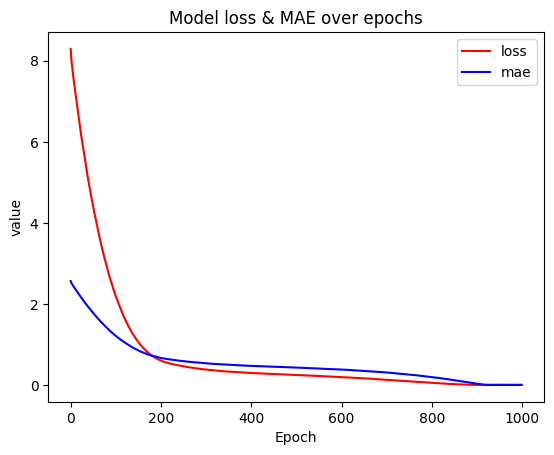

In [32]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend() #범례 label 추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Model loss & MAE over epochs')
plt.show()

In [33]:
# 7. 모델 저장 및 사용
# 학습 후 예측
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 21ms/step


array([[0.3202117 ],
       [0.33822268]], dtype=float32)

In [34]:
model.save('model/after_learning.h5')

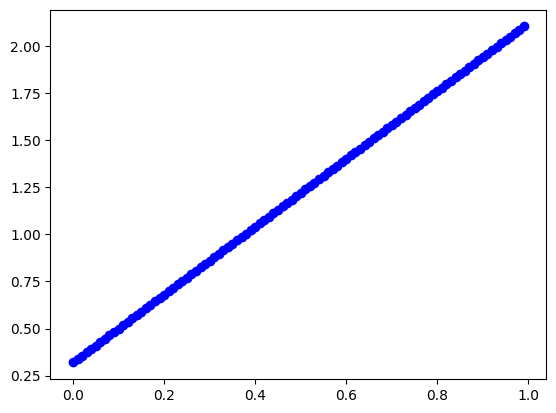

In [36]:
# 실제값
plt.scatter(x=scaled_data_C,
           y=scaled_data_F,
           c='b')
plt.show()

In [40]:
# 예측값
y_hat = model.predict([scaled_data_C])
for h, y in zip(y_hat, scaled_data_F):
    print('예측값:{}, 실제값:{}, 오차:{}'.format(h,
                                      y,
                                      h[0]-y))

4/4 [==============================] - 0s 2ms/step
예측값:[0.3202117], 실제값:0.32, 오차:0.0002117085456848078
예측값:[0.33822268], 실제값:0.33799999999999997, 오차:0.00022268247604373403
예측값:[0.35623372], 실제값:0.35600000000000004, 오차:0.00023371601104732465
예측값:[0.3742447], 실제값:0.374, 오차:0.0002446899414062509
예측값:[0.39225572], 실제값:0.392, 오차:0.000255723476409897
예측값:[0.4102667], 실제값:0.41, 오차:0.00026669740676882325
예측값:[0.42827767], 실제값:0.428, 오차:0.000277671337127694
예측값:[0.4462887], 실제값:0.446, 오차:0.0002887048721313401
예측값:[0.46429974], 실제값:0.46399999999999997, 오차:0.00029973840713504174
예측값:[0.4823107], 실제값:0.48200000000000004, 오차:0.00031071233749385696
예측값:[0.50032175], 실제값:0.5, 오차:0.0003217458724975586
예측값:[0.5183327], 실제값:0.518, 오차:0.0003327198028564293
예측값:[0.5363437], 실제값:0.536, 오차:0.00034369373321530006
예측값:[0.5543547], 실제값:0.554, 오차:0.0003547272682189462
예측값:[0.5723657], 실제값:0.5720000000000001, 오차:0.0003657011985778169
예측값:[0.59037673], 실제값:0.59, 오차:0.00037673473358157405
예측값:[0.6083877], 실제값:0.60

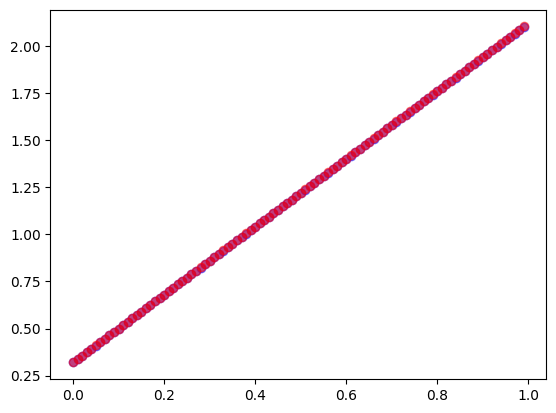

In [41]:
plt.scatter(x=scaled_data_C,
           y=scaled_data_F,
           c='b', alpha=0.5)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', alpha=0.5)

# 2.2 노이즈가 있는 데이터로 실습

In [46]:
np.random.seed(7)
noise = np.random.normal(0, scale=0.1, size=100) #평균 0, 표준편차 0.1개 100개 데이터
noised_scaled_data_F = scaled_data_F+noise

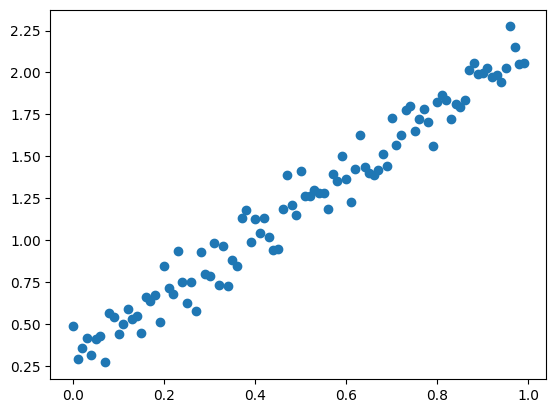

In [47]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [48]:
# 3. 모델구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [49]:
# 5. 모델 학습
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F, epochs=1000, verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.8562 - mae: 1.5275
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.8204 - mae: 1.5168
Epoch 3/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.7922 - mae: 1.5082
Epoch 4/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.7668 - mae: 1.5005
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.7452 - mae: 1.4937
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.7262 - mae: 1.4879
Epoch 7/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.7067 - mae: 1.4820
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6875 - mae: 1.4760
Epoch 9/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.6676 - mae: 1.4698
Epoch 10/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6488 - mae: 1.4640
Epoch 11/1000
4/4 [==============================] - 0s 2ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 0.5525 - mae: 0.6032
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5453 - mae: 0.5994
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5382 - mae: 0.5956
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5306 - mae: 0.5914
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5236 - mae: 0.5875
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5180 - mae: 0.5844
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5117 - mae: 0.5810
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5051 - mae: 0.5773
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4986 - mae: 0.5738
Epoch 183/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4918 - mae: 0.5702
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.1348 - mae: 0.3122
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1341 - mae: 0.3113
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1335 - mae: 0.3106
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1329 - mae: 0.3099
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1322 - mae: 0.3090
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1316 - mae: 0.3082
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1310 - mae: 0.3076
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1305 - mae: 0.3069
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1295 - mae: 0.3058
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1290 - mae: 0.3050
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0481 - mae: 0.1831
Epoch 519/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0477 - mae: 0.1823
Epoch 520/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0474 - mae: 0.1816
Epoch 521/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0470 - mae: 0.1810
Epoch 522/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0467 - mae: 0.1803
Epoch 523/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0463 - mae: 0.1795
Epoch 524/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0459 - mae: 0.1787
Epoch 525/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0456 - mae: 0.1781
Epoch 526/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0452 - mae: 0.1774
Epoch 527/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0448 - mae: 0.1765
Epoch 528/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0133 - mae: 0.0919
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0133 - mae: 0.0918
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0132 - mae: 0.0915
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0132 - mae: 0.0913
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0131 - mae: 0.0910
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0130 - mae: 0.0908
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0130 - mae: 0.0906
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0130 - mae: 0.0905
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0129 - mae: 0.0902
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0128 - mae: 0.0899
Epoch 700/1000
4/4 [==============================] - 0s 3ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0805
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 866/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0807
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

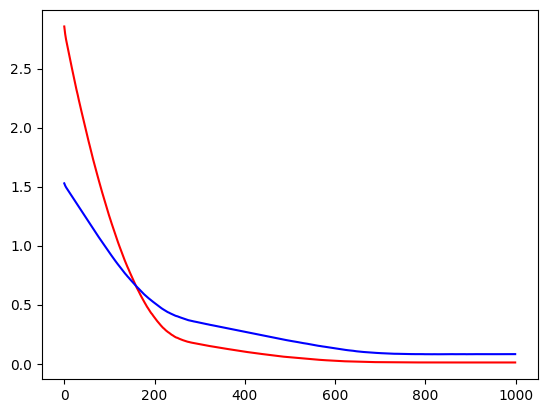

In [52]:
# 6. 학습된 모델과정 살펴보기
plt.plot(hist2.history['loss'], c = 'r')
plt.plot(hist2.history['mae'], c='b')

In [53]:
model.save('model/noise_after_learning.h5')

In [54]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 2ms/step


In [55]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print('실제값:{}, 예측값:{}, 오차:{}'.format(y, h, h[0]-y))

실제값:0.48905257038003563, 예측값:[0.30762094], 오차:-0.18143162778741478
실제값:0.2914062629459167, 예측값:[0.32598305], 오차:0.03457678453943486
실제값:0.3592820163678585, 예측값:[0.34434515], 오차:-0.014936863989776228
실제값:0.4147516282996508, 예측값:[0.3627073], 오차:-0.05204434122651541
실제값:0.31310769713742614, 예측값:[0.3810694], 오차:0.06796169482843994
실제값:0.4102065572905948, 예측값:[0.3994315], 오차:-0.010775060431997996
실제값:0.42791096141420687, 예측값:[0.4177936], 오차:-0.010117359662879355
실제값:0.2705275693654579, 예측값:[0.43615574], 오차:0.1656281670809227
실제값:0.5657658005663493, 예측값:[0.45451784], 오차:-0.11124795922723796
실제값:0.542049851591955, 예측값:[0.47287995], 오차:-0.06916990536011292
실제값:0.43745710260332404, 예측값:[0.49124205], 오차:0.05378494852124871
실제값:0.5008451738804279, 예측값:[0.50960416], 오차:0.008758982136875537
실제값:0.5865299374196752, 예측값:[0.52796626], 오차:-0.058563676509641005
실제값:0.5278643584808353, 예측값:[0.5463284], 오차:0.01846406692657432
실제값:0.5477250921327455, 예측값:[0.5646905], 오차:0.016965378562750155
실제값:0.444675858

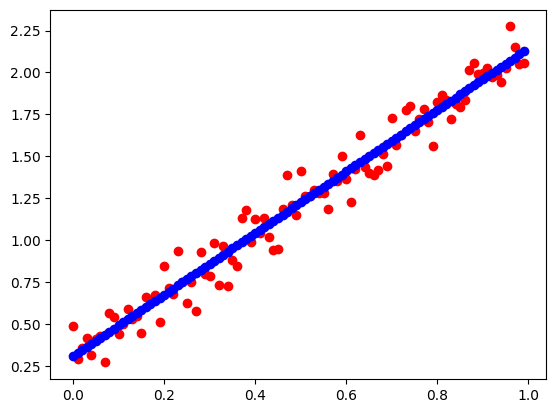

In [56]:
plt.scatter(x=scaled_data_C, 
            y=noised_scaled_data_F,
           c='r')
plt.scatter(x=scaled_data_C,
           y=y_hat,
           c='b')